In [1]:
import os
import illustris_python as il
import numpy as np

basePath = os.path.expanduser("~/Documents/uni/dsp/tng300/outputs")
snap = 99

# subhalo fields
subhalo_fields = [ 
    "SubhaloPos",       # Spatial position within the periodic box (of the particle with the minium gravitational potential energy). Comoving coordinate. Units: ckpc/h 
    "SubhaloVel",       # Peculiar velocity of the group, computed as the sum of the mass weighted velocities of all particles/cells in this group, of all types. No unit conversion is needed. Units: km/s
    "SubhaloMass",      # Total mass of all member particle/cells which are bound to this Subhalo, of all types. Particle/cells bound to subhaloes of this Subhalo are NOT accounted for. Units: 1e10 Msun/h
    "SubhaloMassType",  # Total mass of all member particle/cells which are bound to this Subhalo, separated by type. Particle/cells bound to subhaloes of this Subhalo are NOT accounted for. Units: 1e10 Msun/h
    "SubhaloSFRinRad",  # Sum of the individual star formation rates of all gas cells in this subhalo, but restricted to cells within the radius of 𝑉𝑚𝑎𝑥. Units Msun/yr
    "SubhaloFlag",      # Flag field indicating suitability of this subhalo for certain types of analysis. If zero, this subhalo should generally be excluded, and is not thought to be of cosmological origin.
    "SubhaloGrNr",      # Index into the Group table of the FOF host/parent of this Subhalo. 
    "SubhaloStellarPhotometrics", # Eight bands: U, B, V, K, g, r, i, z. Magnitudes based on the summed-up luminosities of all the stellar particles of the group.
    "SubhaloSFR"        # Sum of the individual star formation rates of all gas cells in this subhalo.
    
]

sub = il.groupcat.loadSubhalos(basePath, snap, fields=subhalo_fields)

## Building a “central galaxy” sample (and why)

### What “central” means here

From https://www.tng-project.org/data/docs/faq/: 

Each FoF halo can have many subhalos: one “central/primary” and zero or more satellites.
The mapping fields you’ll use are:

SubhaloGrNr: subhalo → its parent FoF halo index

GroupFirstSub: FoF halo → the index of its “first / central” subhalo

### Why should we care (for Local Group analogues)

If we search for “pairs separated by 500–1000 kpc” in the full subhalo list, we'll find lots of satellite–satellite or satellite–central pairs inside large clusters and groups. Those are not what we mean by “two primary galaxies like MW and M31”.

Restricting to **centrals** is the simplest first-pass way to:

reduce contamination from dense environments,

reduce the number of objects dramatically (makes k-d tree searches cheaper),

make “pair = two main galaxies in two halos” closer to our intent.

### In the simulation analogue sense

When we look for a Local Group analogue in TNG, the intent is usually:

- pick two separate FoF halos of roughly MW/M31 mass,

- take the central subhalo from each as “MW” and “M31” analogues,

- allow satellites to exist around each, but we're focusing on the two primaries.

This is why the GroupFirstSub trick is useful: it gives us one primary galaxy per halo, so our “pair search” doesn’t accidentally pick two satellites inside a big cluster.

### Practically in the TNG group catalogs:

- Each FoF halo can contain 0 or more subhalos.

- If it contains subhalos, then there is exactly one “central/primary” and the rest are satellites/secondaries.

- The catalog field GroupFirstSub (stored in the Group / halo table) gives the index of the central subhalo for each halo. If a halo has no subhalos, GroupFirstSub == -1.

In [2]:
# Load the minimum halo fields needed for centrality
halos = il.groupcat.loadHalos(basePath, snap, fields=["GroupFirstSub", "GroupNsubs"])
first = halos["GroupFirstSub"]

# We create an array of length sub["count"] and mark those indices listed in GroupFirstSub (excluding -1). 
# GroupFirstSub points into the Subhalo table, so this is the direct way to label central subhalos.
is_central = np.zeros(sub["count"], dtype=bool)

valid = first[first >= 0]     # drop halos with no subhalos
is_central[valid] = True

# Combine centrality with the “useful galaxy” flag
# SubhaloFlag == 1 indicates that the subhalo is of cosmological origin and thus suitable for analysis
keep = (sub["SubhaloFlag"] == 1) & is_central

pos_c = sub["SubhaloPos"][keep]
vel_c = sub["SubhaloVel"][keep]
m_c   = sub["SubhaloMass"][keep]
mtype_c = sub["SubhaloMassType"][keep]
grnr_c  = sub["SubhaloGrNr"][keep]
phot = sub["SubhaloStellarPhotometrics"][keep]
sfr = sub["SubhaloSFR"][keep]

print("All subhalos:", sub["count"])
print("Centrals (raw):", is_central.sum())
print("Centrals with SubhaloFlag==1:", keep.sum())

# Optional: check how many halos have no subhalos
print("Halos with no subhalos:", np.sum(first < 0))

All subhalos: 14485709
Centrals (raw): 11504190
Centrals with SubhaloFlag==1: 11501232
Halos with no subhalos: 6121702


## Stellar mass

Next we to compute stellar mass per central subhalo and keep only objects in a reasonable stellar-mass range. This matters because pair-finding on ~11.5 million centrals will still be heavy, while pair-finding on (say) a few hundred thousand “MW-ish” centrals is manageable.

### What “stellar mass” is in this table

SubhaloMassType is mass by particle type, in units of 1e10 Msun/h. The type mapping is the standard TNG particle-type convention: PartType4 = stars & wind particles, PartType1 = dark matter.

Mstar = SubhaloMassType[:, 4] * 1e10 / h (Msun)

Mdm = SubhaloMassType[:, 1] * 1e10 / h (Msun)

TNG300-1 lists "h" as 0.6774.

In [3]:
# hubble constant 'little h' in units of [100 km/s/Mpc]	0.6774
h = 0.6774  # TNG300-1 "little h" from the downloads page

# Stellar mass from SubhaloMassType:
# SubhaloMassType is in 1e10 Msun/h, and index 4 corresponds to stars & wind particles.
mstar = mtype_c[:, 4] * 1e10 / h  # Msun

# Optional: dark matter mass (same units logic, index 1 is DM).
mdm = mtype_c[:, 1] * 1e10 / h  # Msun

# Choose an initial stellar-mass window.
# This is not a "correct" MW/M31 definition, just a practical starting point to reduce the sample size.
mstar_min = 2e10
mstar_max = 5e11

# Build the filter.
keep_star = (mstar >= mstar_min) & (mstar <= mstar_max)

# Apply it to the central sample arrays.
pos_s   = pos_c[keep_star]
vel_s   = vel_c[keep_star]
mstar_s = mstar[keep_star]
mdm_s   = mdm[keep_star]
grnr_s  = grnr_c[keep_star]
phot_s  = phot[keep_star]
sfr_s   = sfr[keep_star]

print("Centrals before stellar-mass filter:", len(pos_c))
print("Centrals after stellar-mass filter:", len(pos_s))
print("h used:", h)
print("Stellar mass range [Msun]:", mstar_min, "to", mstar_max)

Centrals before stellar-mass filter: 11501232
Centrals after stellar-mass filter: 38778
h used: 0.6774
Stellar mass range [Msun]: 20000000000.0 to 500000000000.0


### Sanity plot (stellar mass vs DM mass) for filtered centrals

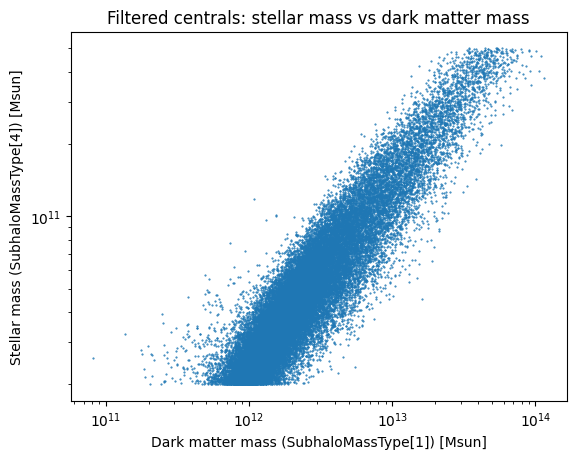

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(mdm_s, mstar_s, ".", markersize=1)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Dark matter mass (SubhaloMassType[1]) [Msun]")
plt.ylabel("Stellar mass (SubhaloMassType[4]) [Msun]")

plt.title("Filtered centrals: stellar mass vs dark matter mass")
plt.show()


### Prepare for pair-finding (define the distance window)

Key detail: SubhaloPos is in ckpc/h (comoving kpc divided by h).
At snapshot 99, z=0, so comoving = physical length, and the conversion to kpc is:

kpc = (ckpc/h) / h

equivalently, ckpc/h = kpc * h

In [5]:
import numpy as np
from scipy.spatial import cKDTree

# To handle periodic boundaries correctly, we need the simulation box size. The group catalog header provides BoxSize in the same units (ckpc/h).

header = il.groupcat.loadHeader(basePath, snap)
box = header["BoxSize"]  # ckpc/h
print("BoxSize [ckpc/h]:", box)

# Distances:
# SubhaloPos is in ckpc/h. The target window is 500–1000 kpc (physical).
# At z=0, converting kpc -> ckpc/h is: ckpc/h = kpc * h.
r_min = 500.0 * h
r_max = 1000.0 * h

# Periodic box size in ckpc/h from the header.
box = header["BoxSize"]  # ckpc/h 

# Build a periodic k-d tree.
# SciPy cKDTree supports periodic boundaries via the 'boxsize' argument. :contentReference[oaicite:3]{index=3}
tree = cKDTree(pos_s, boxsize=box)

# Get all unique index pairs (i < j) with separation <= r_max (in ckpc/h).
pairs = np.array(list(tree.query_pairs(r_max)), dtype=np.int64)

print("Candidate pairs within r_max (before extra cuts):", pairs.shape[0])

# Split indices.
i = pairs[:, 0]
j = pairs[:, 1]

# Exclude pairs that live in the same FoF halo.
# SubhaloGrNr maps each subhalo to its parent FoF halo index. :contentReference[oaicite:4]{index=4}
diff_host = grnr_s[i] != grnr_s[j]
i = i[diff_host]
j = j[diff_host]

print("Pairs after excluding same-host pairs:", i.shape[0])

# Compute separations with the minimum-image convention.
# This is needed to get the correct displacement vector in a periodic box.
dr = pos_s[j] - pos_s[i]
dr -= box * np.round(dr / box)

dist = np.linalg.norm(dr, axis=1)

# Apply the lower bound r_min.
in_window = dist >= r_min
i = i[in_window]
j = j[in_window]
dr = dr[in_window]
dist = dist[in_window]

print("Pairs in [r_min, r_max]:", i.shape[0])

# Convert separation to physical kpc for reporting and plotting.
dist_kpc = dist / h

# Relative velocity vector (km/s).
# SubhaloVel is peculiar velocity in km/s. :contentReference[oaicite:5]{index=5}
dv = vel_s[j] - vel_s[i]

# Radial and tangential relative velocities.
rhat = dr / dist[:, None]
v_r = np.einsum("ij,ij->i", dv, rhat)
v2 = np.einsum("ij,ij->i", dv, dv)
v_t = np.sqrt(np.maximum(0.0, v2 - v_r * v_r))

# -observed radial velocity for later use (formula relating radial peculiar velocity and radial observed velocity. We use radial peculiar velocity for eda)
H0 = 100.0 * h                  
v_hubble = H0 * (dist_kpc / 1000.0)
v_r_obs = v_r + v_hubble


print("Separation stats [kpc]: min/median/max =", np.min(dist_kpc), np.median(dist_kpc), np.max(dist_kpc))
print("v_r stats [km/s]: min/median/max =", np.min(v_r), np.median(v_r), np.max(v_r))
print("v_t stats [km/s]: min/median/max =", np.min(v_t), np.median(v_t), np.max(v_t))

# Formula for total peculiar velocity
v_total = np.sqrt(v_r**2 + v_t**2)

# Applying velocity cuts
velocity_cut = (
    (v_r < 0) &              # approaching because negative LG like
    (v_r > -400) &           
    (v_t < 300) &            # exclude extreme flybys
    (v_total < 500)          # remove unbound encounters
)


# Filter pairs
i_final = i[velocity_cut]
j_final = j[velocity_cut]
v_r_final = v_r[velocity_cut]
v_t_final = v_t[velocity_cut]
dist_kpc_final = dist_kpc[velocity_cut]

print(f"Pairs after velocity filtering: {len(i_final)}")
print(f"v_r [km/s]: min/median/max = {np.min(v_r_final):.1f}, {np.median(v_r_final):.1f}, {np.max(v_r_final):.1f}")
print(f"v_t [km/s]: min/median/max = {np.min(v_t_final):.1f}, {np.median(v_t_final):.1f}, {np.max(v_t_final):.1f}")




BoxSize [ckpc/h]: 205000.0
Candidate pairs within r_max (before extra cuts): 478
Pairs after excluding same-host pairs: 478
Pairs in [r_min, r_max]: 478
Separation stats [kpc]: min/median/max = 535.6242 894.11523 999.6889
v_r stats [km/s]: min/median/max = -946.9707 -98.27925 748.37384
v_t stats [km/s]: min/median/max = 4.026281 123.97529 1626.0802
Pairs after velocity filtering: 354
v_r [km/s]: min/median/max = -374.8, -107.0, -2.6
v_t [km/s]: min/median/max = 4.0, 96.6, 298.5


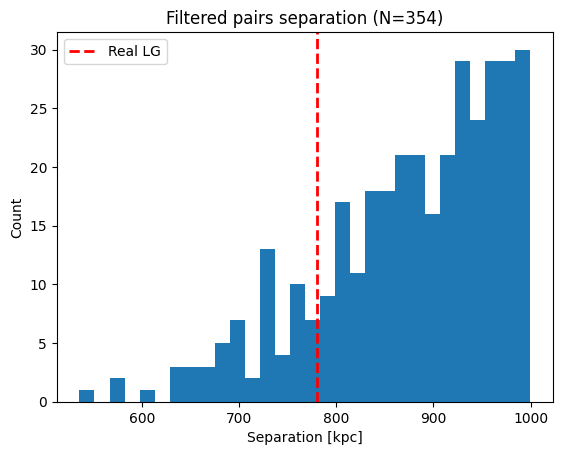

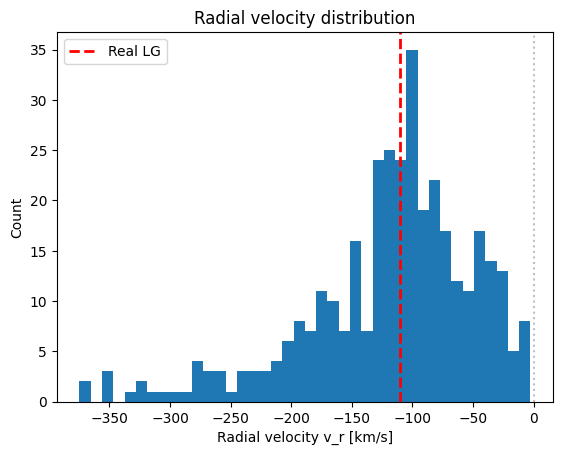

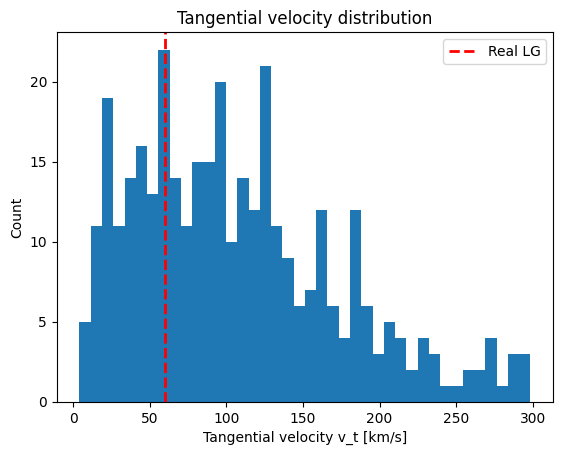

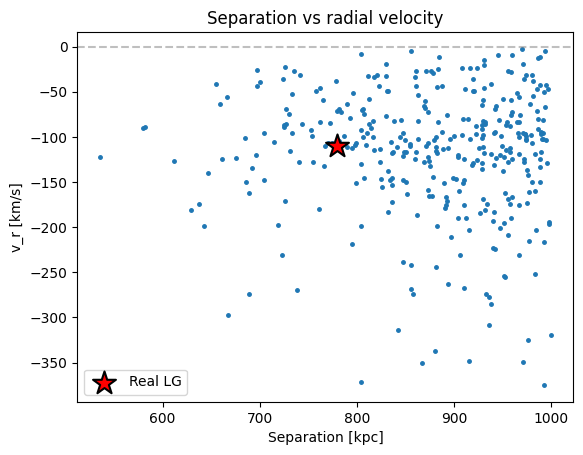

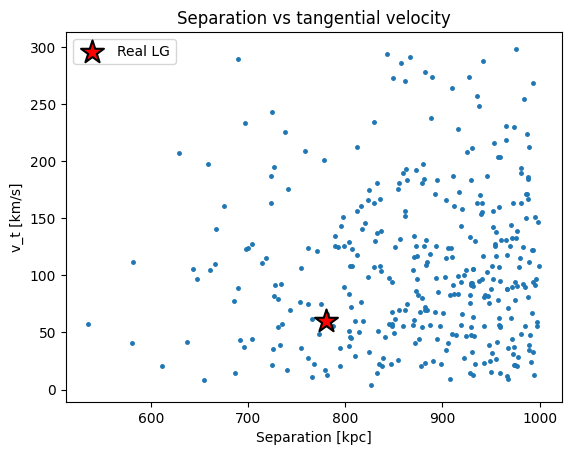

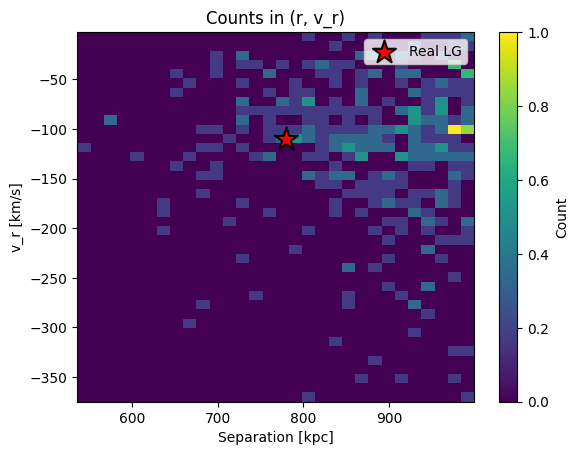

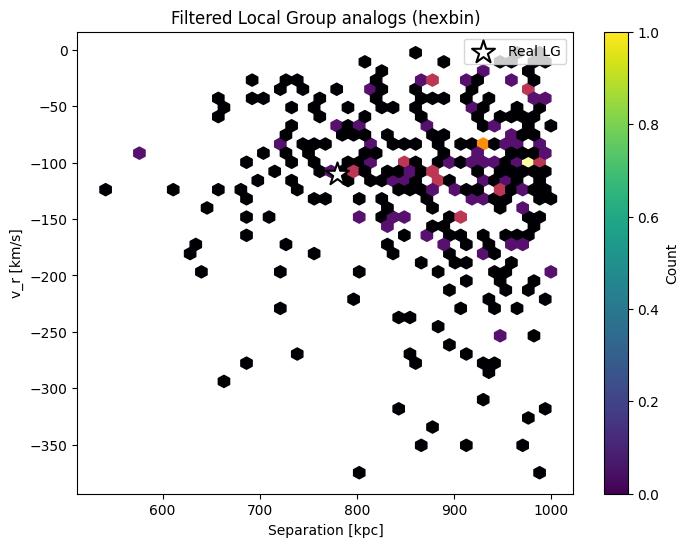


Filtered pairs: 354
Separation range: 535.6 - 999.7 kpc
v_r range: -374.8 - -2.6 km/s
v_t range: 4.0 - 298.5 km/s
Approaching pairs: 354 / 354


In [6]:
import matplotlib.pyplot as plt

# Real Local Group values checked online
LG_sep = 780   # kpc
LG_vr = -110   # km/s
LG_vt = 60     # km/s

# Separation histogram
plt.figure()
plt.hist(dist_kpc_final, bins=30)
plt.axvline(LG_sep, color='red', linestyle='--', linewidth=2, label='Real LG')
plt.xlabel("Separation [kpc]")
plt.ylabel("Count")
plt.title(f"Filtered pairs separation (N={len(dist_kpc_final)})")
plt.legend()
plt.show()

# Radial velocity histogram
plt.figure()
plt.hist(v_r_final, bins=40)
plt.axvline(LG_vr, color='red', linestyle='--', linewidth=2, label='Real LG')
plt.axvline(0, color='gray', linestyle=':', alpha=0.5)
plt.xlabel("Radial velocity v_r [km/s]")
plt.ylabel("Count")
plt.title("Radial velocity distribution")
plt.legend()
plt.show()

# Tangential velocity histogram
plt.figure()
plt.hist(v_t_final, bins=40)
plt.axvline(LG_vt, color='red', linestyle='--', linewidth=2, label='Real LG')
plt.xlabel("Tangential velocity v_t [km/s]")
plt.ylabel("Count")
plt.title("Tangential velocity distribution")
plt.legend()
plt.show()

# Separation vs v_r scatter
plt.figure()
plt.plot(dist_kpc_final, v_r_final, ".", markersize=5)
plt.scatter(LG_sep, LG_vr, marker='*', s=300, color='red', edgecolor='black', linewidth=1.5, label='Real LG', zorder=10)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel("Separation [kpc]")
plt.ylabel("v_r [km/s]")
plt.title("Separation vs radial velocity")
plt.legend()
plt.show()

# Separation vs v_t scatter
plt.figure()
plt.plot(dist_kpc_final, v_t_final, ".", markersize=5)
plt.scatter(LG_sep, LG_vt, marker='*', s=300, color='red', edgecolor='black', linewidth=1.5, label='Real LG', zorder=10)
plt.xlabel("Separation [kpc]")
plt.ylabel("v_t [km/s]")
plt.title("Separation vs tangential velocity")
plt.legend()
plt.show()

# 2D histogram (r, v_r)
plt.figure()
plt.hist2d(dist_kpc_final, v_r_final, bins=[30, 40])
plt.scatter(LG_sep, LG_vr, marker='*', s=300, color='red', edgecolor='black', linewidth=1.5, label='Real LG', zorder=10)
plt.xlabel("Separation [kpc]")
plt.ylabel("v_r [km/s]")
plt.title("Counts in (r, v_r)")
plt.colorbar(label="Count")
plt.legend()
plt.show()

# Heatmap
plt.figure(figsize=(8, 6))
plt.hexbin(dist_kpc_final, v_r_final, gridsize=40, cmap='inferno', mincnt=1)
plt.scatter(LG_sep, LG_vr, marker='*', s=300, color='white', edgecolor='black', linewidth=1.5, label='Real LG', zorder=10)
plt.colorbar(label='Count')
plt.xlabel("Separation [kpc]")
plt.ylabel("v_r [km/s]")
plt.title("Filtered Local Group analogs (hexbin)")
plt.legend()
plt.show()

# Print summary
print(f"\nFiltered pairs: {len(dist_kpc_final)}")
print(f"Separation range: {dist_kpc_final.min():.1f} - {dist_kpc_final.max():.1f} kpc")
print(f"v_r range: {v_r_final.min():.1f} - {v_r_final.max():.1f} km/s")
print(f"v_t range: {v_t_final.min():.1f} - {v_t_final.max():.1f} km/s")
print(f"Approaching pairs: {(v_r_final < 0).sum()} / {len(v_r_final)}")

**Going to calculate M1/M2 ratio and ensure it stays above 1 for more plots. Plotting stellar mass and Dark matter mass ratios and other quantities against mass ratios**

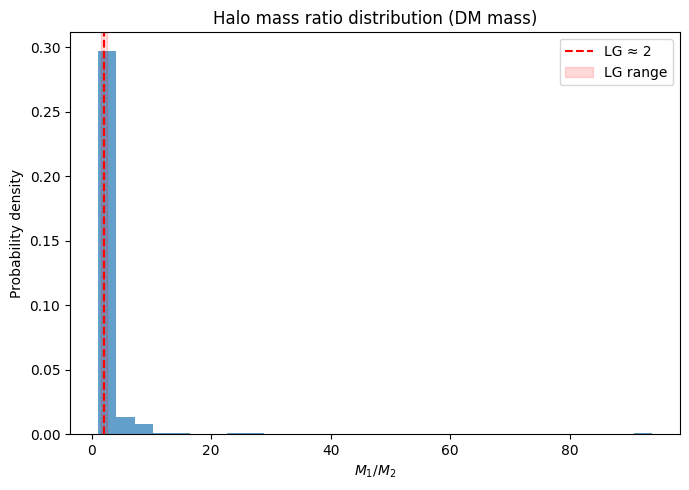

Number of final pairs: 354
Median M1/M2: 1.7267308
16–84 percentile: [1.17782251 3.18726744]
LG-like fraction: 0.3474576271186441


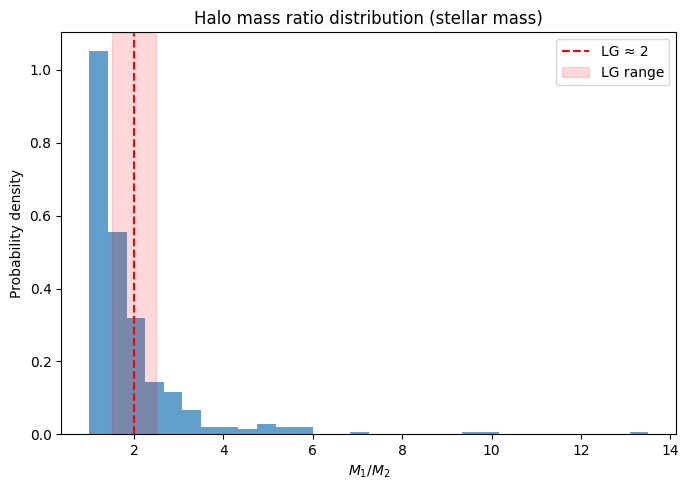

In [7]:
# Halo Dark Matter masses
Mi = mdm_s[i_final]
Mj = mdm_s[j_final]

# Enforce M1 >= M2
M1 = np.maximum(Mi, Mj)
M2 = np.minimum(Mi, Mj)

mass_ratio_dm = M1 / M2

plt.figure(figsize=(7, 5))

plt.hist(
    mass_ratio_dm,
    bins=30,
    density=True,
    alpha=0.7
)

# Local Group reference
plt.axvline(2.0, color="r", linestyle="--", label="LG ≈ 2")
plt.axvspan(1.5, 2.5, color="r", alpha=0.15, label="LG range")

plt.xlabel(r"$M_1 / M_2$")
plt.ylabel("Probability density")
plt.title("Halo mass ratio distribution (DM mass)")
plt.legend()
plt.tight_layout()
plt.show()

print("Number of final pairs:", len(mass_ratio_dm))
print("Median M1/M2:", np.median(mass_ratio_dm))
print("16–84 percentile:", np.percentile(mass_ratio_dm, [16, 84]))

lg_like = np.sum((mass_ratio_dm >= 1.5) & (mass_ratio_dm <= 2.5))
print("LG-like fraction:", lg_like / len(mass_ratio_dm))

# Stellar Masses
Mi_star = mstar_s[i_final]
Mj_star = mstar_s[j_final]

M1_star = np.maximum(Mi_star, Mj_star)
M2_star = np.minimum(Mi_star, Mj_star)

mass_ratio_star = M1_star / M2_star

plt.figure(figsize=(7, 5))

plt.hist(
    mass_ratio_star,
    bins=30,
    density=True,
    alpha=0.7
)

# Local Group reference
plt.axvline(2.0, color="r", linestyle="--", label="LG ≈ 2")
plt.axvspan(1.5, 2.5, color="r", alpha=0.15, label="LG range")

plt.xlabel(r"$M_1 / M_2$")
plt.ylabel("Probability density")
plt.title("Halo mass ratio distribution (stellar mass)")
plt.legend()
plt.tight_layout()
plt.show()




### Trying some scatter plots to find some correlations.

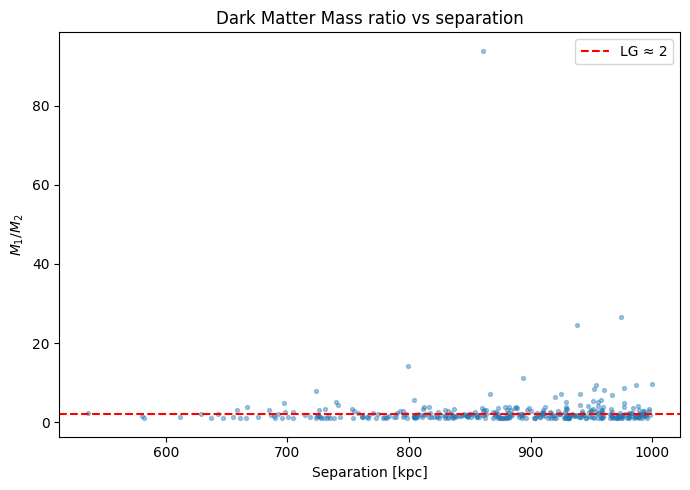

In [8]:
plt.figure(figsize=(7, 5))

plt.scatter(
    dist_kpc_final,
    mass_ratio_dm,
    s=8,
    alpha=0.4
)

plt.axhline(2.0, color="r", linestyle="--", label="LG ≈ 2")

plt.xlabel("Separation [kpc]")
plt.ylabel(r"$M_1 / M_2$")
plt.title("Dark Matter Mass ratio vs separation")
plt.legend()
plt.tight_layout()
plt.show()

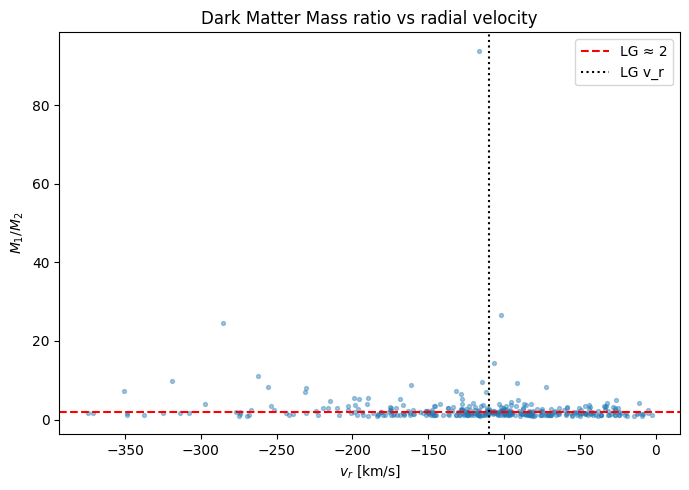

In [9]:
plt.figure(figsize=(7, 5))

plt.scatter(
    v_r_final,
    mass_ratio_dm,
    s=8,
    alpha=0.4
)

plt.axhline(2.0, color="r", linestyle="--", label="LG ≈ 2")
plt.axvline(-110, color="k", linestyle=":", label="LG v_r")

plt.xlabel(r"$v_r$ [km/s]")
plt.ylabel(r"$M_1 / M_2$")
plt.title("Dark Matter Mass ratio vs radial velocity")
plt.legend()
plt.tight_layout()
plt.show()


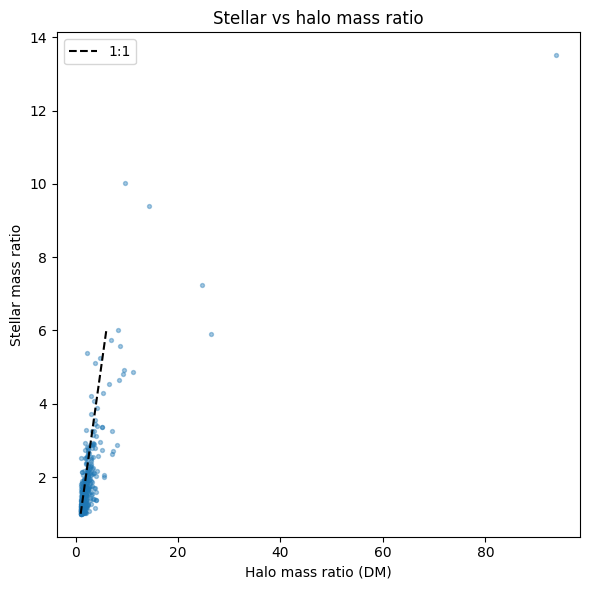

In [10]:
plt.figure(figsize=(6, 6))

plt.scatter(
    mass_ratio_dm,
    mass_ratio_star,
    s=8,
    alpha=0.4
)

plt.plot([1, 6], [1, 6], "k--", label="1:1")

plt.xlabel("Halo mass ratio (DM)")
plt.ylabel("Stellar mass ratio")
plt.title("Stellar vs halo mass ratio")
plt.legend()
plt.tight_layout()
plt.show()


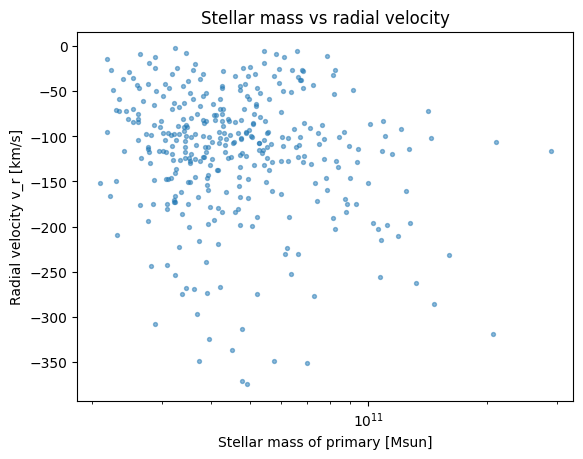

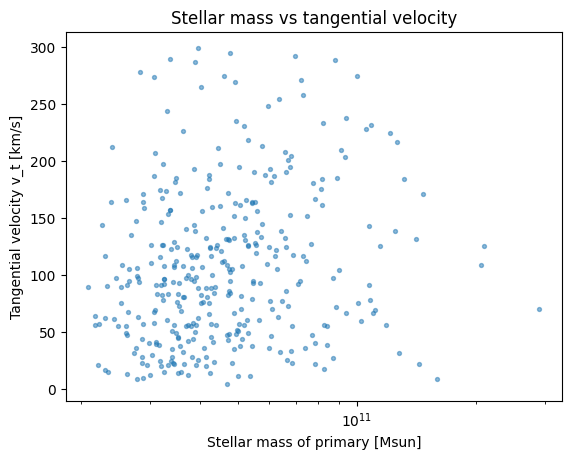

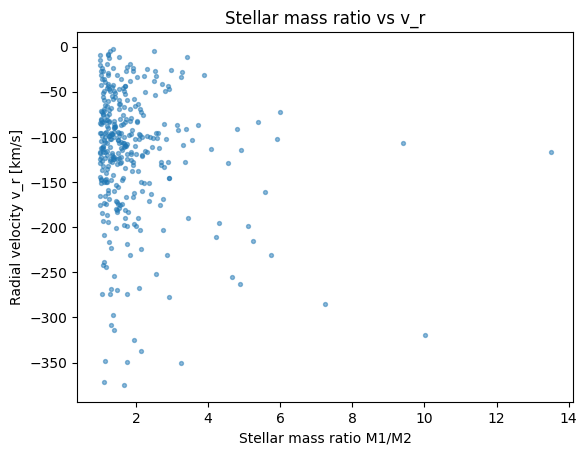

In [11]:
plt.scatter(M1_star, v_r_final, s=8, alpha=0.5)
plt.xscale("log")
plt.xlabel("Stellar mass of primary [Msun]")
plt.ylabel("Radial velocity v_r [km/s]")
plt.title("Stellar mass vs radial velocity")
plt.show()

plt.scatter(M1_star, v_t_final, s=8, alpha=0.5)
plt.xscale("log")
plt.xlabel("Stellar mass of primary [Msun]")
plt.ylabel("Tangential velocity v_t [km/s]")
plt.title("Stellar mass vs tangential velocity")
plt.show()

plt.scatter(mass_ratio_star, v_r_final, s=8, alpha=0.5)
plt.xlabel("Stellar mass ratio M1/M2")
plt.ylabel("Radial velocity v_r [km/s]")
plt.title("Stellar mass ratio vs v_r")
plt.show()


 Does not seem to be any correlation. Everything just seems scattered randomly. Now going to try histograms.

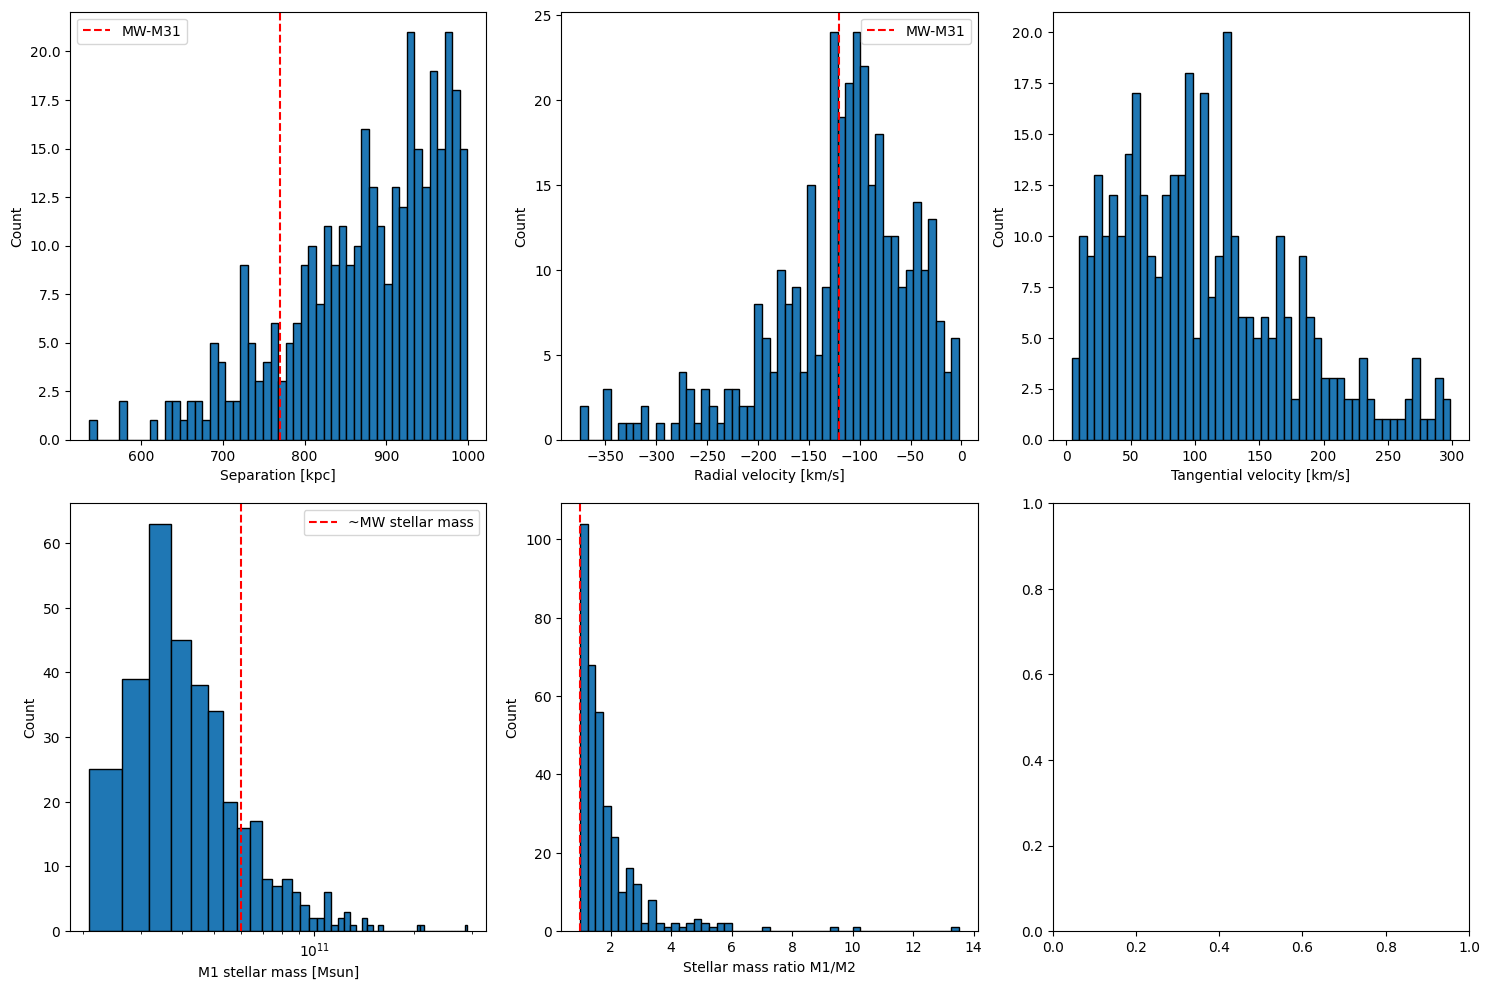

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Separations
axes[0,0].hist(dist_kpc_final, bins=50, edgecolor='black')
axes[0,0].axvline(770, color='red', linestyle='--', label='MW-M31')
axes[0,0].set_xlabel('Separation [kpc]')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# Radial velocity
axes[0,1].hist(v_r_final, bins=50, edgecolor='black')
axes[0,1].axvline(-120, color='red', linestyle='--', label='MW-M31')
axes[0,1].set_xlabel('Radial velocity [km/s]')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# Tangential velocity
axes[0,2].hist(v_t_final, bins=50, edgecolor='black')
axes[0,2].set_xlabel('Tangential velocity [km/s]')
axes[0,2].set_ylabel('Count')

# Stellar mass of primaries
axes[1,0].hist(M1_star, bins=50, edgecolor='black')
axes[1,0].axvline(6e10, color='red', linestyle='--', label='~MW stellar mass')
axes[1,0].set_xlabel('M1 stellar mass [Msun]')
axes[1,0].set_ylabel('Count')
axes[1,0].set_xscale('log')
axes[1,0].legend()

# Mass ratio
axes[1,1].hist(mass_ratio_star, bins=50, edgecolor='black')
axes[1,1].axvline(1, color='red', linestyle='--', label='Equal mass')
axes[1,1].set_xlabel('Stellar mass ratio M1/M2')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Total pairs: 354
LG-like pairs (±1σ observables): 64
Percentage: 18.1%


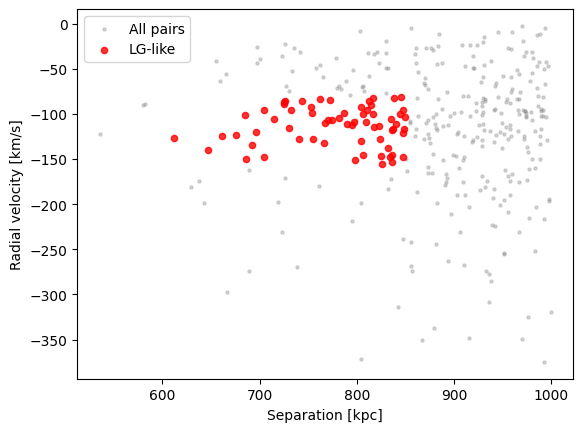

In [13]:
# Define close to local group. Tight constraints for visualization
lg_like = (
    (dist_kpc_final > 600) & (dist_kpc_final < 850) &  # around 780 kpc
    (v_r_final < -80) & (v_r_final > -160) &           # around -120 km/s
    (mass_ratio_star > 1.0) & (mass_ratio_star < 5)    # roughly 1
)

print(f"Total pairs: {len(dist_kpc_final)}")
print(f"LG-like pairs (±1σ observables): {np.sum(lg_like)}")
print(f"Percentage: {100 * np.sum(lg_like) / len(dist_kpc_final):.1f}%")

# Plot these specially
plt.scatter(dist_kpc_final[~lg_like], v_r_final[~lg_like], 
            s=5, alpha=0.3, c='gray', label='All pairs')
plt.scatter(dist_kpc_final[lg_like], v_r_final[lg_like], 
            s=20, alpha=0.8, c='red', label='LG-like')
plt.xlabel('Separation [kpc]')
plt.ylabel('Radial velocity [km/s]')
plt.legend()
plt.show()

## *Photometrics relation with specific star formation rate*

As discussed in the last meeting SubhaloStellarPhotometrics is a logarithmic variable. Difference corresponds to ratio and sum to the product between two values. Keeping this in mind we take the difference to find the color of the pair which is basically the ratio (logarithmic difference).


Color is defined as $$g-r = m_g-m_r$$
And we know from documentation that the indices are U, B, V, K, g, r, i, z. So g and r represent the 4th and the 5th index.

In [14]:
g_r_1 = phot_s[i_final, 4] - phot_s[i_final, 5]
g_r_2 = phot_s[j_final, 4] - phot_s[j_final, 5]


Now we relate to specific star formation rate.

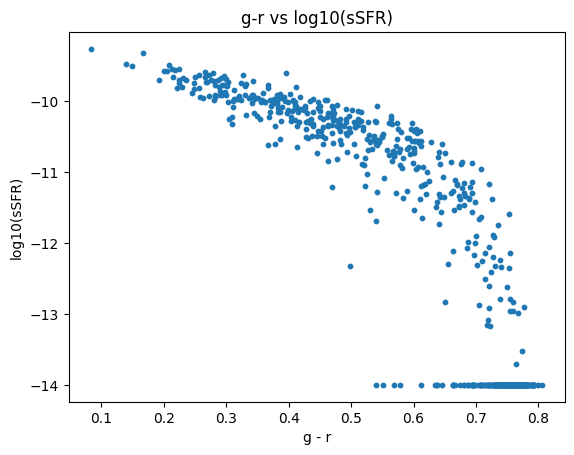

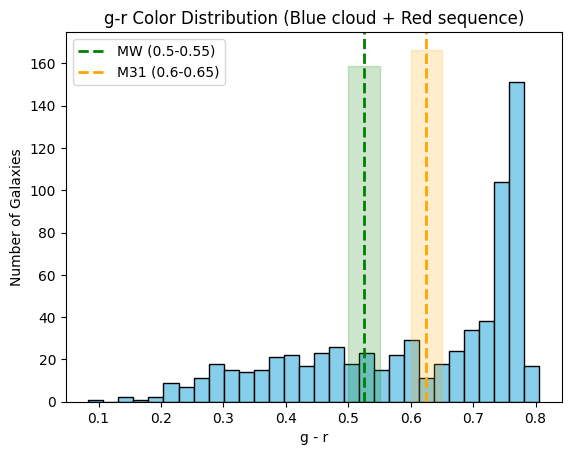

Number of pairs with both members blue: 80 / 354
Fraction of morphologically LG-like pairs: 0.23


In [15]:
ssfr1 = sfr_s[i_final] / Mi_star
ssfr2 = sfr_s[j_final] / Mj_star
ssfr1 = np.where(ssfr1 > 0, ssfr1, 1e-14) # was getting divide by zero error
ssfr2 = np.where(ssfr2 > 0, ssfr2, 1e-14) # 1e-14 physically reasonable for quenched system

log_ssfr1 = np.log10(ssfr1)
log_ssfr2 = np.log10(ssfr2)

g_r_all = np.concatenate([g_r_1, g_r_2])
log_ssfr_all = np.concatenate([log_ssfr1, log_ssfr2])

plt.scatter(g_r_all, log_ssfr_all, s=10)
plt.xlabel("g - r")
plt.ylabel("log10(sSFR)")
plt.title("g-r vs log10(sSFR)")
plt.show()

plt.figure()
plt.hist(g_r_all, bins=30, color='skyblue', edgecolor='k')
plt.xlabel("g - r")
plt.ylabel("Number of Galaxies")
plt.title("g-r Color Distribution (Blue cloud + Red sequence)")
plt.axvline(0.525, color='green', linestyle='--', linewidth=2, label='MW (0.5-0.55)')
plt.axvline(0.625, color='orange', linestyle='--', linewidth=2, label='M31 (0.6-0.65)')
plt.fill_betweenx([0, plt.gca().get_ylim()[1]], 0.5, 0.55, color='green', alpha=0.2)
plt.fill_betweenx([0, plt.gca().get_ylim()[1]], 0.6, 0.65, color='orange', alpha=0.2)
plt.legend()
plt.show()

# Boolean arrays: True = blue (spiral-like) False = red (elliptical-like)
blue_1 = g_r_1 < 0.65
blue_2 = g_r_2 < 0.65

# Count pairs where both are blue
both_blue = np.logical_and(blue_1, blue_2)
num_both_blue = np.sum(both_blue)
total_pairs = len(i_final)

fraction_both_blue = num_both_blue / total_pairs

print(f"Number of pairs with both members blue: {num_both_blue} / {total_pairs}")
print(f"Fraction of morphologically LG-like pairs: {fraction_both_blue:.2f}")



Could possibly remove the points right at the bottom for a smoother plot

Now lets take a look at some luminosity plots and analysis.

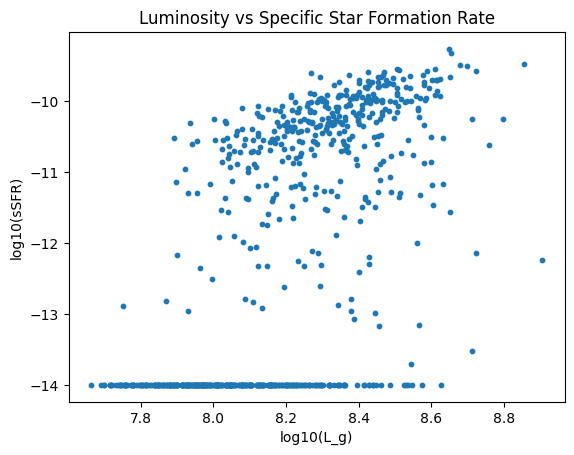

In [16]:
# Compute g - band luminosities
g1 = phot_s[i_final, 4]
g2 = phot_s[j_final, 4]

# Converting to relative luminosity
L1 = 10**(-0.4 * g1)
L2 = 10**(-0.4 * g2)

# Total pair luminosity
L_total = L1 + L2

# Log luminosities
logL1 = np.log10(L1)
logL2 = np.log10(L2)
logL_total = np.log10(L_total)

logL_all = np.concatenate([logL1, logL2])

plt.figure()
plt.scatter(logL_all, log_ssfr_all, s=10)
plt.xlabel("log10(L_g)")
plt.ylabel("log10(sSFR)")
plt.title("Luminosity vs Specific Star Formation Rate")
plt.show()


Again the floor at the bottom of the plot but we could remove it if we are only looking at star formation galaxies. Now Let's look at Color vs Luminosity plot.

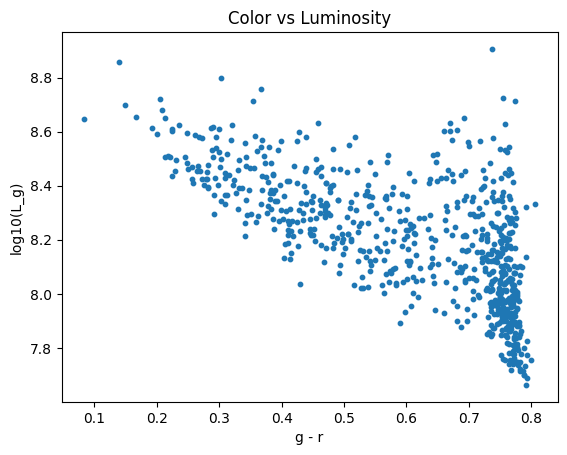

In [17]:
plt.figure()
plt.scatter(g_r_all, logL_all, s=10)
plt.xlabel("g - r")
plt.ylabel("log10(L_g)")
plt.title("Color vs Luminosity")
plt.show()


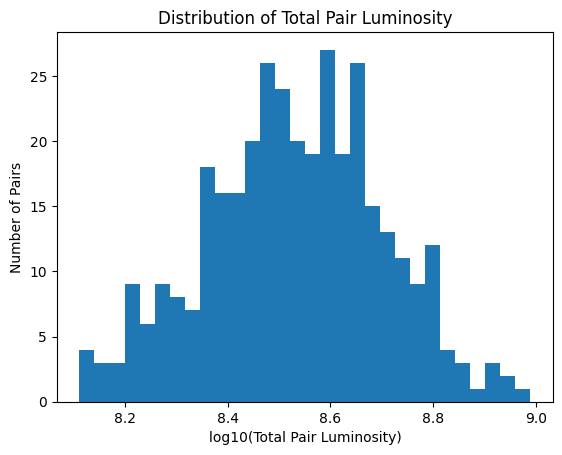

In [18]:
plt.figure()
plt.hist(logL_total, bins=30)
plt.xlabel("log10(Total Pair Luminosity)")
plt.ylabel("Number of Pairs")
plt.title("Distribution of Total Pair Luminosity")
plt.show()


Now lets do B-V Color histogram

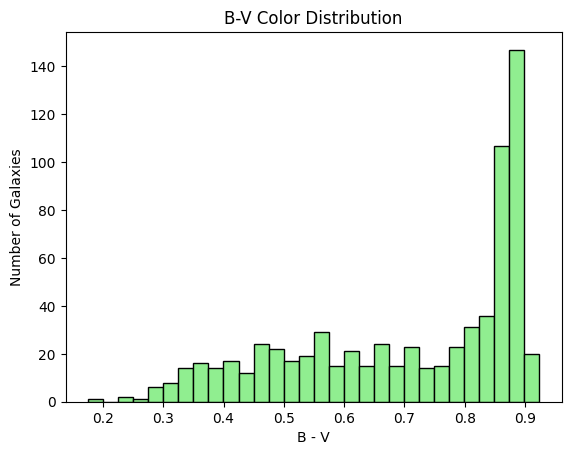

In [19]:
B_V_1 = phot_s[i_final, 1] - phot_s[i_final, 2]
B_V_2 = phot_s[j_final, 1] - phot_s[j_final, 2]

B_V_all = np.concatenate([B_V_1, B_V_2])

plt.figure()
plt.hist(B_V_all, bins=30, color='lightgreen', edgecolor='k')
plt.xlabel("B - V")
plt.ylabel("Number of Galaxies")
plt.title("B-V Color Distribution")
plt.show()


I believe we dont see bimodality because of our stellar mass filtering criteria. Perhaps at LG-analogue masses, most pair members are red/quenched. We found out that only 23% of pairs have both members blue (g-r < 0.65). This is rather interesting because the real MW and M31 are both relatively blue.